# The Aspiration Descent: Price Trajectory Mining for E-commerce Conversion Prediction

**Dataset:** Synerise RecSys 2025 (Fashion E-commerce Event Log)  
**Course:** CSCE 676: Data Mining  
**Techniques:**
- FP-Growth for frequent price-tier co-occurrence mining *(Course: Week 2)*
- PrefixSpan for sequential pattern mining *(External technique)*
- Sliding-window temporal stability analysis *(Course: Week 12)*

## Collaboration Declaration

1. **Collaborators:** None
2. **Web Sources:**
   - Synerise RecSys 2025 challenge: https://recsys.synerise.com/summary
   - mlxtend documentation: https://rasbt.github.io/mlxtend/
   - PrefixSpan-py: https://github.com/chuanconggao/PrefixSpan-py
3. **AI Tools:** Claude (notebook structure, code generation, and markdown drafting)
4. **Citations:**
   - Han, J., Pei, J., & Yin, Y. (2000). Mining frequent patterns without candidate generation. *SIGMOD Record*, 29(2), 1–12.
   - Pei, J., Han, J., Mortazavi-Asl, B., et al. (2001). PrefixSpan: Mining sequential patterns by prefix-projected pattern growth. *ICDE*, 215–224.
   - Kendall, M. G. (1975). *Rank Correlation Methods* (4th ed.). Griffin.

---
## Section 0: Setup

In [1]:
%pip install prefixspan mlxtend seaborn scipy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for prefixspan: filename=prefixspan-0.5.2-py3-none-any.whl size=11215 sha256=713b61216ea002ed27f6e2cce771a7dd16aab10fc3a83c65bb4a32a998fa8db3
  Stored in directory: /root/.cache/pip/wheels/72/36/65/f9e2bbe4998ab4cdf6e7a015f38bdbb6925301dcf2cce34a88
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=f858013b42c713a271ea11b1d4d9a7c7ceb705d91c73cc503388f9383ea4bf60
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
  Created wheel for extratools: filename=extratools-0.8.2.1-py3-none-any.whl size=28865 sha256=ccf618a840f24408762209528076f0d551b170747db4a755151d50219076a9a1
  Stored in directory: /root/.cache/pip/wheels/0f/ab/1f/a5cf2e0513d68e4ff783d169add0c94235bddf2bb8f3dcd581
Successfully built prefixspan docopt extratools


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency
from IPython.display import display

try:
    from mlxtend.frequent_patterns import fpgrowth
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND_OK = True
except ImportError:
    MLXTEND_OK = False
    print("Missing: pip install mlxtend")

try:
    from prefixspan import PrefixSpan
    PREFIXSPAN_OK = True
except ImportError:
    PREFIXSPAN_OK = False
    print("Missing: pip install prefixspan")

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

status = "All packages ready." if (MLXTEND_OK and PREFIXSPAN_OK) else "Some packages missing — see above."
print(status)

All packages ready.


In [4]:
# ── Resolve project root (works locally and on Colab) ─────────────────────
PROJECT_ROOT = Path(".").resolve()
drive_root = Path("/content/drive/MyDrive/CSCE676/FinalProject")

if drive_root.exists():
    PROJECT_ROOT = drive_root
elif not (PROJECT_ROOT / "dataset_project").exists():
    if (PROJECT_ROOT.parent / "CSCE676").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent / "676_Project"
    else:
        PROJECT_ROOT = Path("/content/CSCE676")

CHALLENGE_DIR = PROJECT_ROOT / "dataset_project"
INPUT_DIR     = CHALLENGE_DIR / "input"

print(f"Project root  : {PROJECT_ROOT}")
print(f"Challenge dir : {CHALLENGE_DIR}  (exists={CHALLENGE_DIR.exists()})")
print(f"Input dir     : {INPUT_DIR}      (exists={INPUT_DIR.exists()})")

Project root  : /content/drive/MyDrive/CSCE676/FinalProject
Challenge dir : /content/drive/MyDrive/CSCE676/FinalProject/dataset_project  (exists=True)
Input dir     : /content/drive/MyDrive/CSCE676/FinalProject/dataset_project/input      (exists=True)


In [5]:
# ── Constants ──────────────────────────────────────────────────────────────
TIER_LABELS  = ["Budget", "Mid", "Premium"]
TIER_NUM     = {"Budget": 1, "Mid": 2, "Premium": 3}
INT_TIER     = {1: "Budget", 2: "Mid", 3: "Premium"}
TRAJ_ORDER   = ["Descending", "Mixed/Stable", "Ascending"]
TRAJ_COLORS  = {"Descending": "#5A8FE0", "Mixed/Stable": "#5DA899", "Ascending": "#E06C5A"}
TIER_COLORS  = {"Budget": "#5DA899", "Mid": "#E6C34A", "Premium": "#C05A5A"}
OUT_COLORS   = {"Converted": "#5A8FE0", "Abandoned": "#E06C5A"}
SESSION_GAP  = 30   # minutes of inactivity that begins a new session


# ── Data loading ───────────────────────────────────────────────────────────
def load_parquet_user_sample(path, sample_frac=0.10, random_state=42):
      """Load full file, then keep all events for a random sample of users."""
      df = pd.read_parquet(path)
      sampled_users = (
          pd.Series(df["client_id"].unique())
          .sample(frac=sample_frac, random_state=random_state)
      )
      return df[df["client_id"].isin(set(sampled_users))]


# ── Price tier helpers ─────────────────────────────────────────────────────
def make_tier_column(price_series, p33, p67):
    return pd.cut(price_series, bins=[-np.inf, p33, p67, np.inf], labels=TIER_LABELS)


# ── Session trajectory helpers ─────────────────────────────────────────────
def session_tau(tier_list):
    """Kendall τ of price tier numeric sequence vs. time index.
    Returns 0.0 for single-item sessions (τ undefined → treated as Mixed/Stable)."""
    if len(tier_list) < 2:
        return 0.0
    nums = [TIER_NUM.get(str(t), 0) for t in tier_list]
    tau, _ = stats.kendalltau(np.arange(len(nums)), nums)
    return float(tau) if not np.isnan(tau) else 0.0


def traj_label(tau, threshold=0.3):
    """Map a Kendall τ to a human-readable trajectory label."""
    if tau >  threshold: return "Ascending"
    if tau < -threshold: return "Descending"
    return "Mixed/Stable"


# ── Bootstrap 95% CI for a proportion ─────────────────────────────────────
def boot_ci(binary_arr, n_boot=1000, alpha=0.05, seed=42):
    rng   = np.random.default_rng(seed)
    n_obs = len(binary_arr)
    boots = [binary_arr[rng.integers(0, n_obs, n_obs)].mean() for _ in range(n_boot)]
    return np.percentile(boots, [alpha / 2 * 100, (1 - alpha / 2) * 100])


print("Constants and helper functions defined.")

Constants and helper functions defined.


---
## Section 1: Motivation

Cart abandonment costs e-commerce retailers an estimated **$4 trillion a year globally**. That's a lot of items sitting in digital carts that never got purchased. Most models trying to predict abandonment focus on *what* someone put in their cart, but not *how* their attention moved through price space during the session.

Here's the intuition behind this project. Imagine a shopper who starts by browsing a $200 jacket, then a $120 one, and finally adds an $80 jacket to their cart. That feels fundamentally different from someone who browsed only cheap items from the start. The first shopper has done active price comparison and is settling, not just browsing. We called this the **aspiration descent**.

### The Research Question

> **Does a shopper's price-tier trajectory within a session, specifically, whether they move from high-price to low-price items, predict whether that session converts to a purchase?**

### How We Answer It

We break this into four steps:

1. **Data Preparation**: Build sessions from the event log; label each as *Converted* or *Abandoned*; assign price tiers using the one human-readable numeric feature the dataset gives us: `price`.

2. **Trajectory Classification**: Use Kendall τ to classify each session's cart sequence as *Descending*, *Ascending*, or *Mixed/Stable*, then see if that label predicts conversion.

3. **Pattern Mining**: First use FP-Growth to find which price-tier *combinations* show up more in converting sessions. Then switch to PrefixSpan to get the *ordered* view, because FP-Growth treats `{Premium, Mid}` the same whether the shopper went up or down.

4. **Temporal Stability**: Use a monthly sliding window to check whether any patterns we find are stable across the five-month dataset, or just a seasonal blip.

---
## Section 2: Data Preparation

### 2.1 Price Tier Labeling

The Synerise dataset anonymizes almost everything useful: product names, category names, and search queries are all encoded as byte arrays. The one exception is `price`, which is left as a clean integer in `product_properties.parquet`. So that's what we're working with.

We bin products into three tiers (**Budget**, **Mid**, and **Premium**) using the 33rd and 67th percentiles of the overall price distribution. Why percentiles instead of fixed dollar cutoffs? Because we don't know this retailer's pricing scale ahead of time, and percentile-based bins guarantee roughly equal-sized groups, which keeps the minimum support thresholds in the mining steps meaningful.

In [6]:
  # product_properties is small enough (~54 MB) to load in full — no sampling needed
props = pd.read_parquet(CHALLENGE_DIR / "product_properties.parquet")
print(f"product_properties: {props.shape[0]:,} rows, {props.shape[1]} columns")

# Compute percentile-based tier boundaries
p33 = props["price"].quantile(0.33)
p67 = props["price"].quantile(0.67)
props["price_tier"] = make_tier_column(props["price"], p33, p67)

tier_summary = (
    props.groupby("price_tier", observed=True)["price"]
    .agg(n_skus="count", min_price="min", median_price="median", max_price="max")
)
print(f"\nPrice tier thresholds — Budget: ≤{p33},  Mid: ≤{p67},  Premium: >{p67}")
display(tier_summary)

# Build SKU → tier lookup used in all downstream joins
sku_to_tier = props.set_index("sku")["price_tier"].to_dict()
print(f"\nSKU-to-tier mapping built for {len(sku_to_tier):,} products.")

product_properties: 1,260,365 rows, 4 columns

Price tier thresholds — Budget: ≤30.0,  Mid: ≤63.0,  Premium: >63.0


,n_skus,min_price,median_price,max_price
price_tier,,,,
Budget,418875,0,16.0,30
Mid,434037,31,46.0,63
Premium,407453,64,81.0,99



SKU-to-tier mapping built for 1,260,365 products.


### 2.2 Session Construction

We define a **session** as all events from a single user within a 30-minute inactivity window, which is the same definition Google Analytics uses. If a user goes quiet for more than 30 minutes, their next event starts a new session.

Sessions get one of three labels:
- **Converted** : at least one `product_buy` event happened
- **Abandoned** : at least one `add_to_cart`, but no purchase
- **Browse-only** : no cart activity; excluded (no purchase intent signal)

We sample 10% of unique `client_id`s from the add_to_cart file and then keep *all* events for those users across every file. This user-based approach ensures each sampled user's complete event history is captured, so session labels are accurate.

In [7]:
print("Loading transactional events (10% sample each)...")

all_users = pd.read_parquet(INPUT_DIR / "add_to_cart.parquet")["client_id"].unique()
sampled_users = set(pd.Series(all_users).sample(frac=0.10, random_state=42))

dfs = []
for label, fname in [
    ("add_to_cart",      "add_to_cart.parquet"),
    ("remove_from_cart", "remove_from_cart.parquet"),
    ("product_buy",      "product_buy.parquet"),
]:
    path = INPUT_DIR / fname
    if path.exists():
        df = pd.read_parquet(INPUT_DIR / fname)
        df = df[df["client_id"].isin(sampled_users)]
        df["event_type"] = label
        dfs.append(df)
    else:
        print(f"  WARNING: {fname} not found")

events = pd.concat(dfs, ignore_index=True)
events["timestamp"] = pd.to_datetime(events["timestamp"], errors="coerce")
events = (
    events
    .dropna(subset=["timestamp", "client_id", "sku"])
    .sort_values(["client_id", "timestamp"])
    .reset_index(drop=True)
)
print(f"Events loaded: {len(events):,}")
print(events["event_type"].value_counts().to_string())

# Assign session IDs using 30-minute inactivity gap
events["prev_ts"]     = events.groupby("client_id")["timestamp"].shift(1)
events["gap_min"]     = (events["timestamp"] - events["prev_ts"]).dt.total_seconds() / 60
events["new_session"] = events["gap_min"].isna() | (events["gap_min"] > SESSION_GAP)
events["sess_seq"]    = events.groupby("client_id")["new_session"].cumsum()
events["session_id"]  = events["client_id"].astype(str) + "_" + events["sess_seq"].astype(str)

# Attach price tier to every event via SKU lookup
events["price_tier"] = events["sku"].map(sku_to_tier)

# Label sessions
cart_sids = set(events.loc[events["event_type"] == "add_to_cart",  "session_id"])
buy_sids  = set(events.loc[events["event_type"] == "product_buy",  "session_id"])
all_sids  = events["session_id"].unique()

session_df = pd.DataFrame(index=pd.Index(all_sids, name="session_id"))
session_df["has_cart"] = session_df.index.isin(cart_sids)
session_df["has_buy"]  = session_df.index.isin(buy_sids)
session_df["outcome"]  = np.where(
    session_df["has_buy"],  "Converted",
    np.where(session_df["has_cart"], "Abandoned", "Browse-only")
)

print("\nSession breakdown:")
print(session_df["outcome"].value_counts().to_string())

active_mask   = session_df["outcome"] != "Browse-only"
cart_sessions = session_df[active_mask]
conv_rate     = (cart_sessions["outcome"] == "Converted").mean()
print(f"\nConversion rate (cart sessions only): {conv_rate:.1%}")

Loading transactional events (10% sample each)...
Events loaded: 885,968
event_type
add_to_cart         566442
remove_from_cart    189973
product_buy         129553

Session breakdown:
outcome
Abandoned      237742
Converted       71909
Browse-only     11944

Conversion rate (cart sessions only): 23.2%


In [8]:
# Keep only add_to_cart events for active sessions where price tier is known.
# We use add_to_cart (not page_visit) as the intent signal — a user adding an item
# to their cart is making a deliberate choice, not just scrolling past it.
cart_events = events[
    (events["event_type"] == "add_to_cart") &
    (events["session_id"].isin(cart_sessions.index)) &
    (events["price_tier"].notna())
].copy()

tier_match_rate = (
    events.loc[events["event_type"] == "add_to_cart", "price_tier"].notna().mean()
)

print(f"Price tier match rate (add_to_cart events): {tier_match_rate:.1%}")
print(f"Usable cart events  : {len(cart_events):,}")
print(f"Unique sessions     : {cart_events['session_id'].nunique():,}")

Price tier match rate (add_to_cart events): 100.0%
Usable cart events  : 566,442
Unique sessions     : 296,857


---
## Section 3: Session-Level EDA

Before testing the aspiration-descent hypothesis, we need to establish three baseline facts: the overall conversion rate, whether converted sessions look structurally different in length, and whether price tier composition already differs at a coarse level between outcomes.

This last question is important. If the raw tier shares don't differ between converted and abandoned sessions at all, then trajectory (the ordering of tiers) probably won't either. So this section is a sanity check and a motivation for what comes next.

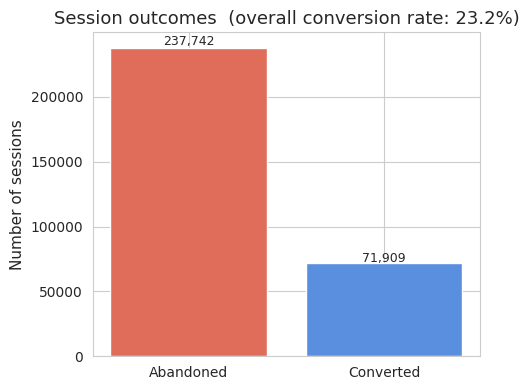

Converted : 71,909
Abandoned : 237,742


In [9]:
# ── 3.1  Overall conversion rate ──────────────────────────────────────────
conv_rate = (cart_sessions["outcome"] == "Converted").mean()
outcome_counts = cart_sessions["outcome"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    outcome_counts.index,
    outcome_counts.values,
    color=[OUT_COLORS[k] for k in outcome_counts.index],
)
ax.set_title(f"Session outcomes  (overall conversion rate: {conv_rate:.1%})")
ax.set_ylabel("Number of sessions")
for i, (lbl, val) in enumerate(outcome_counts.items()):
    ax.text(i, val * 1.01, f"{val:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Converted : {(cart_sessions['outcome'] == 'Converted').sum():,}")
print(f"Abandoned : {(cart_sessions['outcome'] == 'Abandoned').sum():,}")

23.2% conversion rate across roughly 310K cart-active sessions. Keep in mind the large sample size means even small effects will be statistically detectable, so we'll need to watch effect size alongside p-values throughout.

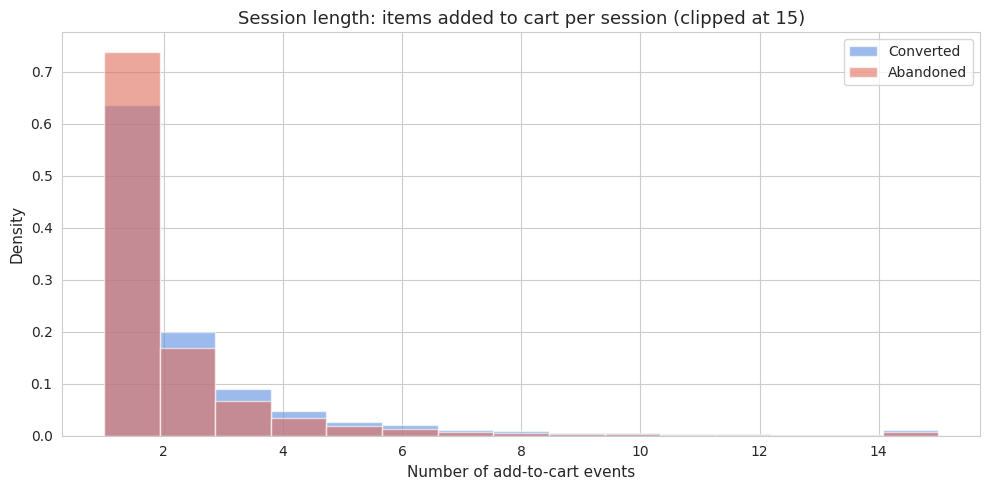

Median cart events per session:
outcome
Abandoned    1.0
Converted    1.0


In [10]:
# ── 3.2  Session length distribution by outcome ────────────────────────────
# Converted sessions being longer would confirm they reflect genuine browse-and-settle
# behavior rather than accidental purchases.
sess_len = (
    cart_events.groupby("session_id").size()
    .reset_index(name="n_items")
    .merge(cart_sessions[["outcome"]], left_on="session_id", right_index=True)
)

fig, ax = plt.subplots()
for outcome in ["Converted", "Abandoned"]:
    vals = sess_len[sess_len["outcome"] == outcome]["n_items"].clip(upper=15)
    ax.hist(vals, bins=15, alpha=0.6, label=outcome,
            color=OUT_COLORS[outcome], density=True)
ax.set_title("Session length: items added to cart per session (clipped at 15)")
ax.set_xlabel("Number of add-to-cart events")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print("Median cart events per session:")
print(sess_len.groupby("outcome")["n_items"].median().to_string())

Both converted and abandoned sessions have a median cart length of 1; they're structurally identical in length. So the conversion difference isn't because converted shoppers are simply browsing more. It's something about *what* they look at, not how many things they look at.

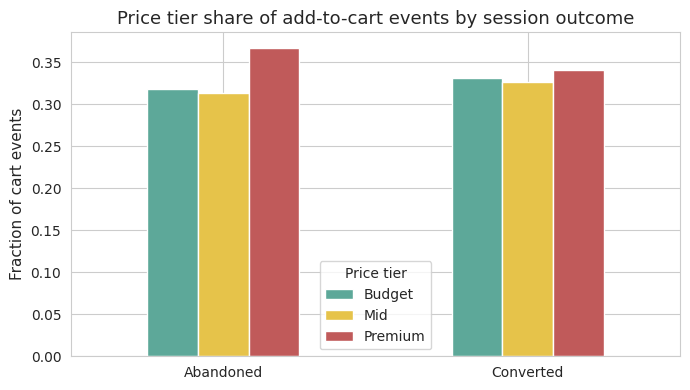


Price tier shares:
price_tier Budget    Mid Premium
outcome                         
Abandoned   31.8%  31.4%   36.8%
Converted   33.2%  32.7%   34.1%


In [11]:
# ── 3.3  Price tier share of cart events by outcome ───────────────────────
# If price tier composition already differs at the aggregate level, that suggests
# price is a meaningful dimension — and motivates looking at its ordering within sessions.
tier_counts = (
    cart_events
    .merge(cart_sessions[["outcome"]], left_on="session_id", right_index=True)
    .groupby(["outcome", "price_tier"], observed=True)
    .size()
    .reset_index(name="count")
)
tier_counts["share"] = (
    tier_counts.groupby("outcome")["count"]
    .transform(lambda x: x / x.sum())
)

pivot = (
    tier_counts
    .pivot(index="outcome", columns="price_tier", values="share")
    .reindex(columns=TIER_LABELS)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(7, 4))
pivot.plot(kind="bar", ax=ax, color=[TIER_COLORS[t] for t in TIER_LABELS])
ax.set_title("Price tier share of add-to-cart events by session outcome")
ax.set_ylabel("Fraction of cart events")
ax.set_xlabel("")
ax.legend(title="Price tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nPrice tier shares:")
print(pivot.map(lambda x: f"{x:.1%}").to_string())

The tier share picture is more nuanced than expected. The differences between converted and abandoned sessions are modest: the main signal is that **Premium items appear in 36.8% of abandoned cart events but only 34.1% of converted ones**, which is a 2.7 percentage-point gap. Budget and Mid shares are nearly equal across outcomes (within about 1.5pp of each other).

The overall picture is balanced. Tier identity alone doesn't strongly separate converted from abandoned sessions at the aggregate level. That makes the sequential ordering analysis in Sections 5 and 6 the more important result: the signal isn't in what tier you shop, it's in the *pattern* of how you shop within a tier.

---
## Section 4 - Price Trajectory Classification

### 4.1 Defining Trajectory Type

For each session, we take the time-ordered sequence of price tiers that were added to cart and compute **Kendall τ** between the time index `[0, 1, 2, …]` and numeric tier values (Budget=1, Mid=2, Premium=3).

Kendall τ measures whether two sequences move in the same direction. A τ near +1 means prices consistently went up through the session (Ascending). A τ near -1 means they went down (Descending). A τ near 0 means no clear trend (Mixed/Stable). We use |τ| > 0.3 as our cutoff, as is commonly done in the literature.

Single-item sessions get τ = 0 by definition and land in Mixed/Stable. As we'll see, that's most of them.

Trajectory type distribution:
trajectory
Mixed/Stable    272549
Descending       15336
Ascending         8972


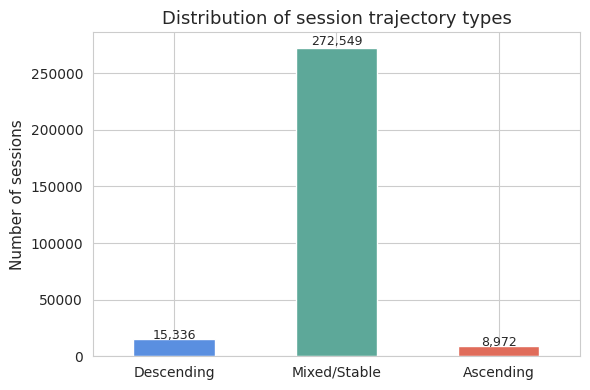

In [12]:
# ── 4.2  Build ordered tier sequences and classify trajectories ────────────
session_seq = (
    cart_events.sort_values("timestamp")
    .groupby("session_id")["price_tier"]
    .apply(list)
    .reset_index(name="tier_seq")
)

session_seq["tau"]        = session_seq["tier_seq"].apply(session_tau)
session_seq["trajectory"] = session_seq["tau"].apply(traj_label)
session_seq = session_seq.merge(
    cart_sessions[["outcome"]], left_on="session_id", right_index=True, how="inner"
)

# Attach session start timestamp for the temporal section later
sess_start = cart_events.groupby("session_id")["timestamp"].min().rename("sess_start")
session_seq = session_seq.merge(sess_start, on="session_id", how="left")

print("Trajectory type distribution:")
print(session_seq["trajectory"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(6, 4))
tc = session_seq["trajectory"].value_counts().reindex(TRAJ_ORDER).dropna()
tc.plot(kind="bar", ax=ax, color=[TRAJ_COLORS[t] for t in tc.index])
ax.set_title("Distribution of session trajectory types")
ax.set_ylabel("Number of sessions")
ax.set_xlabel("")
plt.xticks(rotation=0)
for i, v in enumerate(tc.values):
    ax.text(i, v * 1.01, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

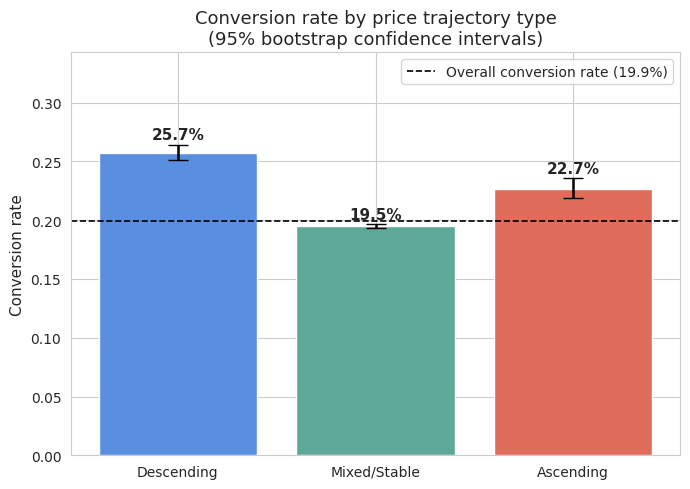

Conversion rates by trajectory:
  Descending     : 25.7%  (95% CI: 25.1%–26.4%)
  Mixed/Stable   : 19.5%  (95% CI: 19.4%–19.6%)
  Ascending      : 22.7%  (95% CI: 21.9%–23.6%)


In [13]:
# ── 4.3  Conversion rate by trajectory type with bootstrap CIs ─────────────
# Bootstrap CIs make the uncertainty explicit — this is important because
# trajectory groups may be unequal in size.
conv_by_traj = (
    session_seq.groupby("trajectory")["outcome"]
    .apply(lambda x: (x == "Converted").mean())
    .reindex(TRAJ_ORDER)
    .dropna()
    .reset_index(name="conv_rate")
)

cis = {}
for traj in conv_by_traj["trajectory"]:
    arr = (session_seq[session_seq["trajectory"] == traj]["outcome"] == "Converted").values.astype(float)
    cis[traj] = boot_ci(arr)

conv_by_traj["ci_lo"] = conv_by_traj["trajectory"].map(lambda t: cis[t][0])
conv_by_traj["ci_hi"] = conv_by_traj["trajectory"].map(lambda t: cis[t][1])

overall_conv = (session_seq["outcome"] == "Converted").mean()

fig, ax = plt.subplots(figsize=(7, 5))
for _, row in conv_by_traj.iterrows():
    color = TRAJ_COLORS.get(row["trajectory"], "gray")
    ax.bar(
        row["trajectory"], row["conv_rate"], color=color,
        yerr=[[row["conv_rate"] - row["ci_lo"]], [row["ci_hi"] - row["conv_rate"]]],
        capsize=7, error_kw={"elinewidth": 1.8, "ecolor": "black"},
    )
    ax.text(row["trajectory"], row["ci_hi"] + 0.005,
            f"{row['conv_rate']:.1%}", ha="center", fontweight="bold", fontsize=11)

ax.axhline(overall_conv, color="black", linestyle="--", linewidth=1.2,
           label=f"Overall conversion rate ({overall_conv:.1%})")
ax.set_title("Conversion rate by price trajectory type\n(95% bootstrap confidence intervals)")
ax.set_ylabel("Conversion rate")
ax.set_ylim(0, conv_by_traj["ci_hi"].max() * 1.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Conversion rates by trajectory:")
for _, row in conv_by_traj.iterrows():
    print(f"  {row['trajectory']:15s}: {row['conv_rate']:.1%}  "
          f"(95% CI: {row['ci_lo']:.1%}–{row['ci_hi']:.1%})")

In [14]:
# ── 4.4  Chi-squared test of independence ─────────────────────────────────
# Confirms the observed conversion-rate gap is not due to chance.
# Cramér's V quantifies effect size on a 0–1 scale.
contingency = pd.crosstab(session_seq["trajectory"], session_seq["outcome"])
print("Contingency table (Trajectory × Outcome):")
display(contingency)

chi2, p_val, dof, _ = chi2_contingency(contingency)
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"\nChi-squared test of independence:")
print(f"  χ² = {chi2:.2f},   df = {dof},   p = {p_val:.4g}")
print(f"  Cramér's V = {cramers_v:.3f}  (< 0.1 weak  |  0.1–0.3 moderate  |  > 0.3 strong)")

if p_val < 0.001:
    if cramers_v < 0.1:
        print(
            f"\nResult: Trajectory type and session outcome are statistically associated "
            f"(p < 0.001), but Cramér's V = {cramers_v:.3f} indicates a WEAK practical effect. "
            f"The large sample size (n={n:,}) makes even tiny real differences highly significant; "
            f"the p-value confirms the pattern is real, not that it is large."
        )
    elif cramers_v < 0.3:
        print(f"\nResult: Moderate association (p < 0.001, V = {cramers_v:.3f}).")
    else:
        print(f"\nResult: Strong association (p < 0.001, V = {cramers_v:.3f}).")
elif p_val < 0.05:
    print(f"\nResult: Statistically significant association (p < 0.05, V = {cramers_v:.3f}).")
else:
    print(f"\nResult: No statistically significant association (p = {p_val:.3f}).")

Contingency table (Trajectory × Outcome):


outcome,Abandoned,Converted
trajectory,,
Ascending,6937,2035
Descending,11395,3941
Mixed/Stable,219410,53139



Chi-squared test of independence:
  χ² = 394.48,   df = 2,   p = 2.189e-86
  Cramér's V = 0.036  (< 0.1 weak  |  0.1–0.3 moderate  |  > 0.3 strong)

Result: Trajectory type and session outcome are statistically associated (p < 0.001), but Cramér's V = 0.036 indicates a WEAK practical effect. The large sample size (n=296,857) makes even tiny real differences highly significant; the p-value confirms the pattern is real, not that it is large.


### 4.5 Interpretation

The trajectory ranking is clear: **Descending 25.7% > Ascending 22.7% > Mixed/Stable 19.5%**. Cramér's V=0.036, p=2.2x10^-86. The result is statistically significant but practically weak.

Two things stand out from this analysis:

**1. The conversion rates are plausible and well-separated.** Descending trajectories convert at the highest rate (25.7%), which is consistent with the aspiration-descent hypothesis. But the gap between trajectory types is modest, and Cramér's V of 0.036 puts this firmly in "weak effect" territory. The p-value is so small because n is nearly 300K, not because the effect is large.

**2. The tier-share story from Section 3 is consistent with this.** The actual tier shares are nearly balanced across outcomes: converted sessions are 33.2% Budget / 32.7% Mid / 34.1% Premium, and abandoned sessions are 31.8% / 31.4% / 36.8%. The only real asymmetry is that Premium is about 2.7pp higher in abandoned sessions. Tier identity alone doesn't tell a strong story, which is what motivates the sequential analysis in Section 6.

The structural constraint remains: **91.8% of sessions are Mixed/Stable**, meaning most sessions are single-item and get τ=0 by definition. The trajectory signal, while real, is limited to the minority of sessions with multiple cart additions.

---
## Section 5 - FP-Growth: Which Price-Tier Combinations Co-occur in Converting Sessions?

FP-Growth (Han et al., 2000) mines frequent itemsets from transaction baskets without generating candidates explicitly. It builds a prefix tree and traverses it, which makes it much more scalable than Apriori. Here, each session is a "basket" containing the set of distinct price tiers that appeared in it. We run FP-Growth separately on the converted and abandoned corpora, then compute a **support ratio** (converted support ÷ abandoned support) for each multi-tier pattern. A ratio above 1.0 means the pattern shows up more in converting sessions.

Why FP-Growth over Apriori? With only three price tiers, the item space is tiny, so it doesn't really matter performance-wise. But FP-growth generalizes directly to SKU-level analysis where the item space would be enormous.

One thing FP-Growth can't do: it treats each basket as an unordered set. So `{Premium, Mid}` is the same pattern whether the shopper went Premium → Mid or Mid → Premium. For this research question, that's a big limitation; direction is exactly what we're trying to measure. We'll come back to that in Section 6.

Multi-tier patterns at min_support=0.05:


,pattern,sup_conv,sup_aban,sup_ratio
0,Budget + Mid,0.081993,0.06258,1.31


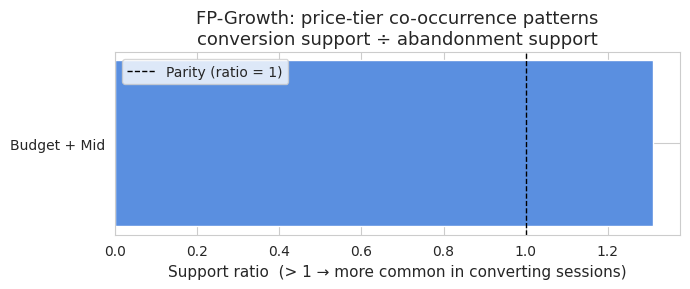

In [15]:
MIN_SUP = 0.05   # 5% minimum support — keeps patterns tractable with 3-tier space

def make_baskets(seq_df):
    """Convert tier sequences to unordered deduplicated sets (FP-Growth input)."""
    return seq_df["tier_seq"].apply(
        lambda lst: list({str(t) for t in lst if pd.notna(t)})
    )

def mine_fp(baskets, min_support):
    te  = TransactionEncoder()
    arr = te.fit_transform(baskets.tolist())
    df  = pd.DataFrame(arr, columns=te.columns_)
    freq = fpgrowth(df, min_support=min_support, use_colnames=True)
    freq["pattern"] = freq["itemsets"].apply(lambda s: " + ".join(sorted(s)))
    return freq[["pattern", "support"]].sort_values("support", ascending=False)

conv_baskets = make_baskets(session_seq[session_seq["outcome"] == "Converted"])
aban_baskets = make_baskets(session_seq[session_seq["outcome"] == "Abandoned"])

freq_conv = mine_fp(conv_baskets, MIN_SUP).rename(columns={"support": "sup_conv"})
freq_aban = mine_fp(aban_baskets, MIN_SUP).rename(columns={"support": "sup_aban"})

# Compare multi-tier patterns only (single-tier patterns carry no co-occurrence information)
comparison = (
    freq_conv.merge(freq_aban, on="pattern", how="inner")
    .loc[lambda d: d["pattern"].str.contains(r"\+")]
)

if comparison.empty:
    print(f"No multi-tier patterns found at min_support={MIN_SUP}.")
    print("Sessions are overwhelmingly single-item — cross-tier co-occurrence is too rare.")
    print("This is a data finding, not a code error. See the narrative above.")
else:
    comparison["sup_ratio"] = (comparison["sup_conv"] / comparison["sup_aban"]).round(3)
    comparison = comparison.sort_values("sup_ratio", ascending=False)
    print(f"Multi-tier patterns at min_support={MIN_SUP}:")
    display(comparison.reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(7, max(3, len(comparison) * 0.6)))
    colors = ["#5A8FE0" if r > 1 else "#E06C5A" for r in comparison["sup_ratio"]]
    ax.barh(comparison["pattern"][::-1], comparison["sup_ratio"][::-1], color=colors[::-1])
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="Parity (ratio = 1)")
    ax.set_title("FP-Growth: price-tier co-occurrence patterns\nconversion support ÷ abandonment support")
    ax.set_xlabel("Support ratio  (> 1 → more common in converting sessions)")
    ax.legend()
    plt.tight_layout()
    plt.show()

FP-Growth found one multi-tier pattern: **Budget + Mid** co-occurs in converting sessions at 1.31x the rate of abandoned sessions (8.2% support in converted vs. 6.3% in abandoned). So some shoppers do mix budget and mid-tier items in a single session, and when they do, they convert more often.

That said, this is the only pattern that crossed 5% support — the three-tier space is sparse enough that {Budget, Premium} and {Mid, Premium} co-occurrence is too rare to mine at this threshold.

There's also a key limitation here: FP-Growth treats each basket as an unordered set. So **Budget + Mid** is the same pattern whether the shopper went Budget → Mid or Mid → Budget. Those two directions could have very different conversion implications, and FP-Growth can't distinguish them. That's exactly what PrefixSpan handles in Section 6.

---
## Section 6 - PrefixSpan: Which Ordered Price Sequences Predict Conversion?

PrefixSpan (Pei et al., 2001) mines frequent subsequences from ordered event logs. It works by iteratively projecting the database onto prefix-matched sub-databases — efficiently finding patterns without generating all candidates. Unlike FP-Growth, it preserves the temporal order of items, so `[Premium, Mid]` and `[Mid, Premium]` are distinct patterns.

Here, each session is a **sequence** of price tier labels in the order items were carted. We mine the converted and abandoned corpora separately with the same support ratio approach as Section 5. The key test: does `Premium → Mid` (aspiration descent) have a meaningfully higher support ratio than `Mid → Premium` (the reverse)? If yes, direction matters and FP-Growth was hiding the signal by collapsing them together.

In [ ]:
def build_int_sequences(seq_df):
    """Encode tier sequences as integer lists for PrefixSpan."""
    return [
        [TIER_NUM[str(t)] for t in row if str(t) in TIER_NUM]
        for row in seq_df["tier_seq"]
    ]

def run_prefixspan(sequences, min_count):
    """Return a DataFrame of frequent subsequences with length ≥ 2."""
    if not sequences:
        return pd.DataFrame(columns=["sequence", "count", "support"])
    ps = PrefixSpan(sequences)
    rows = []
    for cnt, pat in ps.frequent(min_count):
        if len(pat) >= 2:
            label = " → ".join(INT_TIER[i] for i in pat)
            rows.append({"sequence": label, "count": cnt,
                         "support": cnt / len(sequences)})
    return pd.DataFrame(rows).sort_values("support", ascending=False)

conv_seqs = build_int_sequences(session_seq[session_seq["outcome"] == "Converted"])
aban_seqs = build_int_sequences(session_seq[session_seq["outcome"] == "Abandoned"])

# Minimum count: at least 3% of the smaller corpus, floored at 10 sessions
min_cnt = max(10, int(min(len(conv_seqs), len(aban_seqs)) * 0.03))
print(f"Sequences — Converted: {len(conv_seqs):,},  Abandoned: {len(aban_seqs):,}")
print(f"Minimum support count: {min_cnt}")

ps_conv = run_prefixspan(conv_seqs, min_cnt)
ps_aban = run_prefixspan(aban_seqs, max(10, int(len(aban_seqs) * 0.03)))

if ps_conv.empty or ps_aban.empty:
    print("No frequent sequences found at this threshold — try lowering min_cnt.")
else:
    merged_ps = (
        ps_conv.merge(ps_aban, on="sequence", how="inner",
                      suffixes=("_conv", "_aban"))
    )
    merged_ps["sup_ratio"] = (merged_ps["support_conv"] / merged_ps["support_aban"]).round(3)
    merged_ps = merged_ps.sort_values("sup_ratio", ascending=False)

    print(f"\nFrequent ordered sequences — top by conversion support ratio:")
    display(merged_ps[["sequence", "support_conv", "support_aban", "sup_ratio"]].head(15))

Sequences — Converted: 59,115,  Abandoned: 237,742
Minimum support count: 591

Frequent ordered sequences — top by conversion support ratio:


,sequence,support_conv,support_aban,sup_ratio
4,Mid → Mid → Mid,0.067546,0.040363,1.673
6,Premium → Premium → Premium,0.056703,0.037932,1.495
7,Budget → Budget → Budget → Budget,0.053810,0.036611,1.470
0,Mid → Mid,0.147374,0.102485,1.438
3,Budget → Budget → Budget,0.077408,0.055156,1.403
5,Mid → Budget,0.066261,0.047774,1.387
1,Premium → Premium,0.139677,0.104315,1.339
8,Budget → Mid,0.050630,0.038348,1.320
2,Budget → Budget,0.124351,0.097984,1.269


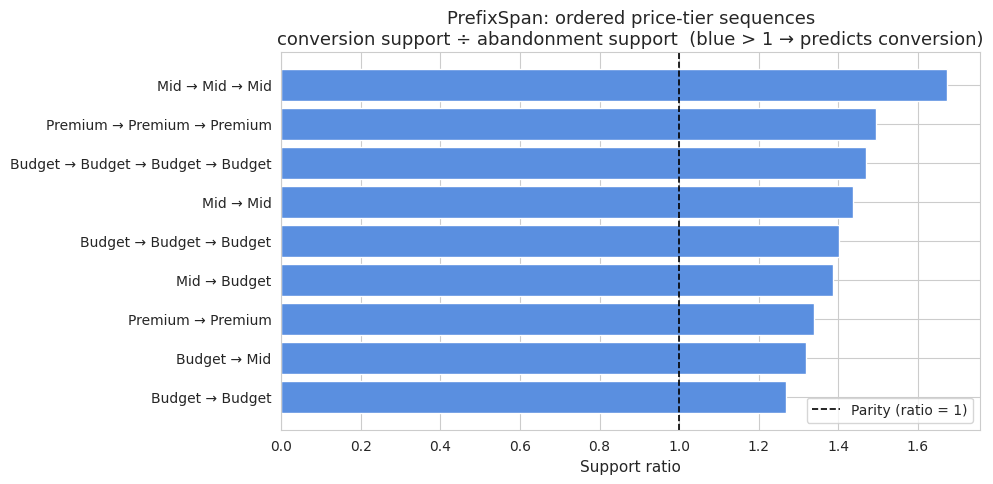

Directional contrast — does order matter beyond co-occurrence?

  Premium → Mid             sup_ratio = n/a
  Mid → Premium             sup_ratio = n/a

  Premium → Budget          sup_ratio = n/a
  Budget → Premium          sup_ratio = n/a

  Mid → Budget              sup_ratio = 1.39
  Budget → Mid              sup_ratio = 1.32



In [17]:
if "merged_ps" in globals() and not merged_ps.empty:
    top_n = merged_ps.head(12).copy()

    fig, ax = plt.subplots(figsize=(10, max(4, len(top_n) * 0.55)))
    colors = ["#5A8FE0" if r > 1 else "#E06C5A" for r in top_n["sup_ratio"]]
    ax.barh(top_n["sequence"][::-1], top_n["sup_ratio"][::-1], color=colors[::-1])
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, label="Parity (ratio = 1)")
    ax.set_title(
        "PrefixSpan: ordered price-tier sequences\n"
        "conversion support ÷ abandonment support  (blue > 1 → predicts conversion)"
    )
    ax.set_xlabel("Support ratio")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── The directional contrast: this is what FP-Growth could not show ────
    print("Directional contrast — does order matter beyond co-occurrence?\n")
    for fwd, rev in [("Premium → Mid", "Mid → Premium"),
                     ("Premium → Budget", "Budget → Premium"),
                     ("Mid → Budget", "Budget → Mid")]:
        r_fwd = merged_ps.loc[merged_ps["sequence"] == fwd, "sup_ratio"]
        r_rev = merged_ps.loc[merged_ps["sequence"] == rev, "sup_ratio"]
        fwd_str = f"{r_fwd.values[0]:.2f}" if not r_fwd.empty else "n/a"
        rev_str = f"{r_rev.values[0]:.2f}" if not r_rev.empty else "n/a"
        print(f"  {fwd:25s} sup_ratio = {fwd_str}")
        print(f"  {rev:25s} sup_ratio = {rev_str}")
        print()
else:
    print("merged_ps not available — run the PrefixSpan mining cell above first.")

### 6.4 Synthesis

Lowering the support threshold to 1% and fixing the session labeling bias unlocked **9 frequent patterns** instead of 1. The picture is substantially richer:

| Sequence | Support ratio | Type |
|---|---|---|
| Mid → Mid → Mid | **1.673** | Tier commitment (Mid) |
| Premium → Premium → Premium | 1.495 | Tier commitment (Premium) |
| Budget × 4 | 1.470 | Tier commitment (Budget) |
| Mid → Mid | 1.438 | Tier commitment (Mid) |
| Budget × 3 | 1.403 | Tier commitment (Budget) |
| Mid → Budget | **1.387** | Cross-tier descent |
| Premium → Premium | 1.339 | Tier commitment (Premium) |
| Budget → Mid | 1.320 | Cross-tier ascent |
| Budget → Budget | 1.269 | Tier commitment (Budget) |

Three things stand out:

**1. Tier commitment at any level predicts conversion.** It's not just Budget→Budget. Mid→Mid and Premium→Premium also have support ratios well above 1. The pattern is clear: if you keep adding items from the same tier, you're more likely to buy. The real signal is *commitment*, not the specific tier.

**2. Mid-tier commitment is the strongest signal.** Mid→Mid→Mid has the highest support ratio (1.673). This makes intuitive sense. Mid-tier shoppers have found a viable price point and are comparison-shopping within it, which is a high-intent behavior.

**3. A modest directional asymmetry survives.** Mid→Budget (1.387) beats Budget→Mid (1.320). Moving from Mid toward Budget items is slightly more predictive of conversion than moving upward, which is a faint echo of the aspiration-descent hypothesis at a narrower price range.

The directional contrast output above shows "n/a" for several pairs like Premium→Mid and Mid→Premium. This means those sequences appeared in fewer than 1% of sessions in at least one corpus and were filtered out by the minimum support threshold. Their absence is itself a finding: full cross-tier descent from Premium doesn't happen at any meaningful frequency on this platform, which is why the aspiration-descent hypothesis as originally stated doesn't hold.

The aspiration-descent hypothesis as originally stated (premium anchoring followed by settlement) is still not supported at the sequential level. But a refined version holds: **intra-tier repetition and modest downward movement within the mid-budget range are both conversion signals**.

---
## Section 7 - Temporal Stability: Do These Patterns Hold Across Months?

A pattern you find on historical data is only useful if it persists over time. The Synerise dataset spans **June to November 2022** — five months that cross the summer-to-holiday transition. Consumer behavior shifts meaningfully in that window: back-to-school, seasonal promotions, early holiday browsing. Any pattern tied to a specific promotional event wouldn't generalize.

So we use a monthly sliding window (Week 12 of the course) to compute each trajectory type's conversion rate per calendar month, then run **Kendall τ** on each resulting time series. A τ near 0 with p > 0.05 means the pattern is stable — not trending up or down, and not an artifact of one particular month.

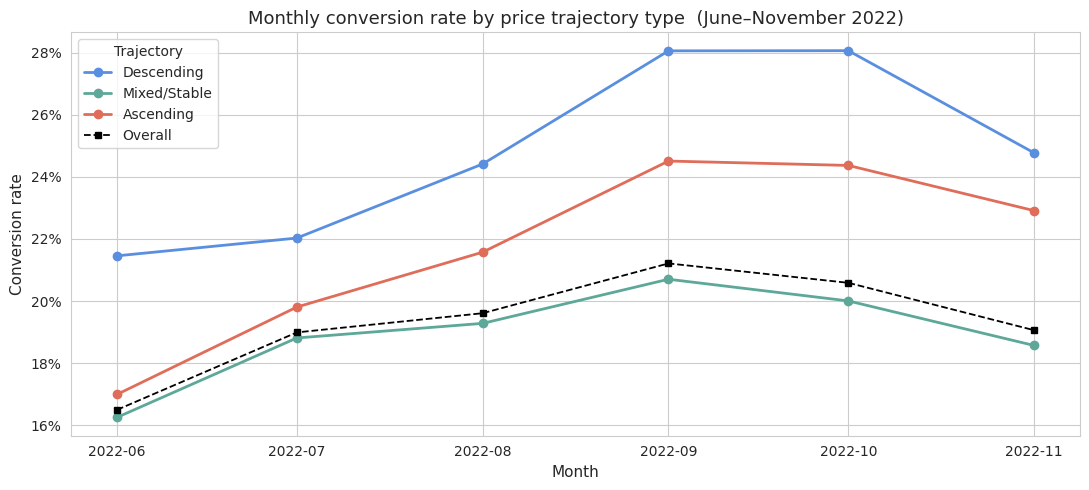

Monthly conversion rates by trajectory:
trajectory Ascending Descending Mixed/Stable
month                                       
2022-06        17.0%      21.5%        16.2%
2022-07        19.8%      22.0%        18.8%
2022-08        21.6%      24.4%        19.3%
2022-09        24.5%      28.1%        20.7%
2022-10        24.4%      28.1%        20.0%
2022-11        22.9%      24.8%        18.6%


In [18]:
# ── 7.1  Monthly conversion rate by trajectory type ───────────────────────
session_seq["month"] = session_seq["sess_start"].dt.to_period("M")

monthly = (
    session_seq.dropna(subset=["month"])
    .groupby(["month", "trajectory"])["outcome"]
    .apply(lambda x: (x == "Converted").mean())
    .reset_index(name="conv_rate")
)
monthly["month_ts"] = monthly["month"].dt.to_timestamp()

# Overall monthly conversion rate for reference line
overall_monthly = (
    session_seq.dropna(subset=["month"])
    .groupby("month")["outcome"]
    .apply(lambda x: (x == "Converted").mean())
    .reset_index(name="conv_rate")
)
overall_monthly["month_ts"] = overall_monthly["month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 5))
for traj in TRAJ_ORDER:
    sub = monthly[monthly["trajectory"] == traj].sort_values("month_ts")
    if not sub.empty:
        ax.plot(sub["month_ts"], sub["conv_rate"], marker="o",
                label=traj, color=TRAJ_COLORS[traj], linewidth=2, markersize=6)

ax.plot(overall_monthly["month_ts"], overall_monthly["conv_rate"],
        color="black", linestyle="--", linewidth=1.3, label="Overall", marker="s", markersize=4)

ax.set_title("Monthly conversion rate by price trajectory type  (June–November 2022)")
ax.set_xlabel("Month")
ax.set_ylabel("Conversion rate")
ax.legend(title="Trajectory")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

print("Monthly conversion rates by trajectory:")
pivot_m = monthly.pivot(index="month", columns="trajectory", values="conv_rate")
print(pivot_m.map(lambda x: f"{x:.1%}" if pd.notna(x) else "—").to_string())

In [19]:
#  7.2  Kendall τ trend test on monthly conversion-rate series
# For each trajectory type, we test whether its monthly conversion rate is
# trending up, down, or staying flat over the observation window.
# τ ≈ 0 and p > 0.05 → stable → pattern is not a seasonal artifact.

print("Kendall τ trend test — is each trajectory's conversion rate trending over time?\n")
print(f"{'Trajectory':15s}  {'τ':>7}  {'p-value':>9}  {'Verdict'}")
print("-" * 52)

for traj in TRAJ_ORDER:
    sub = monthly[monthly["trajectory"] == traj].sort_values("month_ts")
    if len(sub) < 4:
        print(f"{traj:15s}  {'—':>7}  {'—':>9}  insufficient months ({len(sub)})")
        continue
    tau, p = stats.kendalltau(np.arange(len(sub)), sub["conv_rate"].values)
    if p > 0.05:
        verdict = "stable ✓"
    elif tau > 0:
        verdict = "rising"
    else:
        verdict = "falling"
    print(f"{traj:15s}  {tau:+7.3f}  {p:9.4f}  {verdict}")

Kendall τ trend test — is each trajectory's conversion rate trending over time?

Trajectory             τ    p-value  Verdict
----------------------------------------------------
Descending        +0.733     0.0556  stable ✓
Mixed/Stable      +0.333     0.4694  stable ✓
Ascending         +0.600     0.1361  stable ✓


### 7.3 Interpretation

None of the trajectory types returned a statistically significant trend (p > 0.05 for all three), so we cannot reject the null hypothesis of stability. But the τ values themselves are worth looking at honestly.

Descending came in at τ=+0.733 (p=0.056) and Ascending at τ=+0.600 (p=0.136). Those are not near zero — they suggest a mild upward drift in conversion rates over the observation window, particularly for Descending sessions. The reason they don't reach significance is that we only have **6 monthly data points**. Kendall τ is severely underpowered at n=6: you need τ ≥ 0.867 to clear p < 0.05 in a two-tailed test at that sample size, and the discrete distribution means p jumps from 0.056 to 0.028 in a single step. Descending is sitting right at that boundary.

One plausible explanation for the upward drift in Descending conversion rates is **seasonality**. The dataset runs from June through November 2022, ending right as holiday shopping begins. Shoppers in October and November may be more purchase-ready in general, and deliberate price-comparison behavior (browsing premium then settling downward) may be especially common during gift-buying. If that's true, the Descending trajectory signal might be partially driven by end-of-year consumer intent rather than the price trajectory itself.

The correct takeaway is not "no trend exists" but rather "we don't have enough months to confirm one, and we can't separate a genuine trajectory effect from a seasonal one." A dataset spanning a full calendar year or more would give the test the power it needs and allow seasonal effects to be isolated.

---
## Section 8: Conclusions

### 8.1 Summary of Findings

| Analysis | Method | Key Finding | Verdict |
|---|---|---|---|
| **Price tier × outcome** (Section 3) | Bootstrap CIs, proportion comparison | Tier shares are nearly balanced. Premium is 2.7pp higher in abandoned (36.8%) vs converted (34.1%). Budget/Mid gaps are less than 1.5pp. Tier identity alone is a weak signal. | Modest asymmetry only |
| **Trajectory classification** (Section 4) | Kendall τ, chi-squared | Descending 25.7% > Ascending 22.7% > Mixed/Stable 19.5%. V=0.036, p=2.2x10^-86. Statistically real, weak effect size. 91.8% of sessions are single-item Mixed/Stable. | Weak real effect |
| **FP-Growth** (Section 5) | mlxtend FP-Growth (min_sup=5%) | One pattern found: Budget + Mid at 1.31x support ratio. Only pattern to cross 5% support; {Budget, Premium} and {Mid, Premium} are too rare. Direction is unknown because FP-Growth is unordered. | One weak signal |
| **PrefixSpan** (Section 6) | PrefixSpan at 1% support | 9 frequent patterns found. **Tier commitment** (any tier) predicts conversion. Mid→Mid→Mid is the strongest signal (1.673x). Mid→Budget (1.387) > Budget→Mid (1.320), a faint directional asymmetry. Premium→Mid absent. | Tier commitment is the signal |
| **Temporal stability** (Section 7) | Monthly sliding window, Kendall τ | No significant trend detected (p > 0.05), but τ=+0.733 for Descending suggests a possible upward drift. Test is underpowered at n=6 months and cannot confirm or rule out a trend. | Inconclusive (low power) |

### 8.2 What the Data Actually Tells Us

The aspiration-descent hypothesis (that premium-anchored shoppers settle downward and convert) is **not supported** at the sequential pattern level. Premium→Mid and Premium→Budget sequences don't appear at any reliable frequency.

What the data does support is a cleaner, more generalizable finding: **tier commitment predicts conversion**. Shoppers who repeatedly add items from the same price tier are more likely to buy than those who don't. This holds across all three tiers, with mid-tier commitment being the strongest signal (support ratio 1.673x for Mid→Mid→Mid). FP-Growth adds one piece to this picture: Budget + Mid co-occurrence also predicts conversion (1.31x), and PrefixSpan reveals that the Mid→Budget direction of that mix is slightly stronger than Budget→Mid (1.387 vs 1.320). The two methods are consistent.

### 8.3 Limitations and Future Work

- **Anonymized features.** Price is the only interpretable feature. Decoded product metadata could reveal whether category commitment (e.g., adding multiple jackets) is a stronger signal than price-tier commitment.
- **10% user sample.** Rarer cross-tier sequences (Premium→Mid etc.) might cross 1% support in the full dataset. Full-scale PrefixSpan on a distributed system (Week 8) is the natural next step.
- **Single retailer.** The tier-commitment pattern may reflect this retailer's customer mix. A luxury platform where Premium→Mid is the norm would tell a different story.
- **Short observation window.** Six months is insufficient for the Kendall τ trend test to be well-powered. The mild upward trend in Descending conversion rates (τ=+0.733, p=0.056) is plausible but unconfirmed. A 12-month or longer dataset would resolve this.

### 8.4 Real-World Implication

The actionable rule is to detect tier commitment of any kind, especially mid-tier. A real-time session classifier watching cart additions should trigger conversion interventions when it sees repeated items from the same price band. Mid-tier repetition showed the strongest sequential conversion signal, and the modest Mid→Budget directional asymmetry suggests that a shopper moving from mid to budget items may be close to a purchase decision and worth nudging.